# Introdução

O câncer de mama é uma das doenças mais frequentes no mundo, e o diagnóstico precoce desempenha um papel fundamental no aumento das chances de tratamento e recuperação. Nesse contexto, técnicas de Inteligência Artificial têm se destacado como ferramentas de apoio à tomada de decisão médica, permitindo a construção de modelos capazes de identificar padrões em diferentes tipos de dados.

Neste Tech Challenge, foi utilizado o Wisconsin Breast Cancer Dataset, disponível no Kaggle, para treinar e avaliar modelos de Random Forest a partir de dados tabulares, com otimização de hiperparâmetros via Algoritmo Genético (AG).

Além da parte preditiva, este notebook incorpora a camada de **integração com uma LLM (Claude, da Anthropic)**, adaptada para interpretar as saídas do Random Forest: transformar as métricas numéricas do modelo em explicações em linguagem natural, gerar um relatório executivo e avaliar automaticamente a qualidade dessas explicações (checagens heurísticas + LLM-as-judge).

# Tópicos

1- Introdução <br>
2- Importação das bibliotecas e dos dados <br>
3- Conhecendo os dados <br>
4- Preparação dos dados <br>
5- Escolha do modelo (supervisionado) — Random Forest <br>
6- Treinar o modelo <br>
7- Otimização de hiperparâmetros com Algoritmo Genético <br>
8- Testes <br>
9- Integração com Claude para interpretação dos resultados <br>
10- Relatório executivo gerado pelo Claude <br>
11- Avaliação da qualidade das interpretações geradas <br>
12- Conclusão geral <br>

## 1. Bibliotecas e dados

#Importação das bibliotecas e dos dados

*   Dataset de câncer de mama Wisconsin
*   Problema binário: Diagnóstico do exame, podendo ser **maligno** ou **benigno**
*   Abordagem: Aprendizado supervisionado

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

random.seed(42)
np.random.seed(42)

!gdown --id "1z3JF1r6ixWJsp_C6rDeWCHXP1kUIxQtD"

/Users/ph/playground/FIAP-TC-F02/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ph/playground/FIAP-TC-F02/.venv/lib/python3.9/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1z3JF1r6ixWJsp_C6rDeWCHXP1kUIxQtD
To: /Users/ph/playground/FIAP-TC-F02/data.csv
100%|███████████████████████████████████████| 125k/125k [00:00<00:00, 2.00MB/s]


#Exibição dos dados

In [2]:
# Nome do arquivo
file_name = 'data.csv'

# Carrega o CSV para um DataFrame
df = pd.read_csv(f"./{file_name}")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Preparação dos dados

*   Dataset escolhido: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data
*   Nome do arquivo: data.csv
*   Bibliotecas importadas até aqui: pandas, numpy, matplotlib, scikit-learn

In [3]:
df = df.drop(columns=["id", "Unnamed: 32"])

df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

Treino: 398
Validação: 85
Teste: 86


# Modelo original

Primeiro será treinado um Random Forest simples. Esse resultado será usado como referência para comparar com o modelo encontrado pelo algoritmo genético.

In [4]:
modelo_original = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42
)

modelo_original.fit(X_train, y_train)

pred_original = modelo_original.predict(X_test)

accuracy_original = accuracy_score(y_test, pred_original)
recall_original = recall_score(y_test, pred_original)
f1_original = f1_score(y_test, pred_original)

print("Accuracy:", round(accuracy_original, 4))
print("Recall:", round(recall_original, 4))
print("F1-score:", round(f1_original, 4))

Accuracy: 0.9767
Recall: 0.9375
F1-score: 0.9677


# 1. Representação dos indivíduos

Cada indivíduo será uma lista com quatro genes:

```text
[n_estimators, max_depth, min_samples_split, max_features]
```

In [5]:
from src.ga import (
    N_ESTIMATORS_OPCOES,
    MAX_DEPTH_OPCOES,
    MIN_SAMPLES_SPLIT_OPCOES,
    MAX_FEATURES_OPCOES,
    criar_individuo,
)

criar_individuo()

[120, 2, 2, None]

# 2. Função fitness

O **F1-score** será utilizado como fitness.

Cada indivíduo cria um Random Forest com os hiperparâmetros representados pelos seus genes. O modelo é treinado no conjunto de treino e avaliado no conjunto de validação.

In [6]:
from src.ga import calcular_fitness

# 3. Elitização

A população será ordenada pelo fitness e apenas a metade com melhor resultado poderá gerar novos indivíduos.

In [7]:
from src.ga import selecionar

# 4. Cruzamento

O cruzamento será feito utilizando um ponto de corte.

Os primeiros genes vêm de um pai e os genes restantes vêm do outro.

In [8]:
from src.ga import cruzar

# 5. Mutação

Durante a mutação, existe uma chance de um dos genes receber um novo valor aleatório.

In [9]:
from src.ga import mutar

# 6. Algoritmo genético

A cada geração:

1. todos os indivíduos são avaliados;
2. a metade com melhor fitness é selecionada;
3. novos indivíduos são criados por cruzamento;
4. alguns indivíduos sofrem mutação;
5. a nova população substitui a anterior.

Será mantido apenas o melhor indivíduo da geração anterior para evitar perder uma solução boa.

In [10]:
from src.ga import algoritmo_genetico

# 7. Experimentos

Serão feitos três experimentos alterando tamanho da população, número de gerações e taxa de mutação.

In [11]:
experimentos = [
    [8, 8, 0.10],
    [10, 10, 0.20],
    [12, 12, 0.30]
]

resultados = []

for i in range(3):

    print("\nEXPERIMENTO", i + 1)

    populacao = experimentos[i][0]
    geracoes = experimentos[i][1]
    mutacao = experimentos[i][2]

    melhor, fitness, historico_melhor, historico_media = algoritmo_genetico(
        populacao,
        geracoes,
        mutacao,
        X_train,
        y_train,
        X_val,
        y_val,
    )

    resultados.append([
        melhor,
        fitness,
        historico_melhor,
        historico_media
    ])

    print("Melhor indivíduo:", melhor)
    print("Melhor fitness:", round(fitness, 4))


EXPERIMENTO 1
Geração 1 - Melhor: 0.9333 - Média: 0.9152
Geração 2 - Melhor: 0.9508 - Média: 0.9339
Geração 3 - Melhor: 0.9508 - Média: 0.9399
Geração 4 - Melhor: 0.9508 - Média: 0.9421
Geração 5 - Melhor: 0.9508 - Média: 0.9467
Geração 6 - Melhor: 0.9508 - Média: 0.9508
Geração 7 - Melhor: 0.9508 - Média: 0.9445
Geração 8 - Melhor: 0.9508 - Média: 0.9486
Melhor indivíduo: [120, 10, 6, 'sqrt']
Melhor fitness: 0.9508

EXPERIMENTO 2
Geração 1 - Melhor: 0.9508 - Média: 0.934
Geração 2 - Melhor: 0.9508 - Média: 0.9375
Geração 3 - Melhor: 0.9508 - Média: 0.9491
Geração 4 - Melhor: 0.9508 - Média: 0.9508
Geração 5 - Melhor: 0.9508 - Média: 0.9508
Geração 6 - Melhor: 0.9508 - Média: 0.9491
Geração 7 - Melhor: 0.9508 - Média: 0.9475
Geração 8 - Melhor: 0.9508 - Média: 0.9508
Geração 9 - Melhor: 0.9508 - Média: 0.9508
Geração 10 - Melhor: 0.9508 - Média: 0.9491
Melhor indivíduo: [120, 12, 4, 'log2']
Melhor fitness: 0.9508

EXPERIMENTO 3
Geração 1 - Melhor: 0.9508 - Média: 0.9264
Geração 2 - Me

# 8. Evolução das gerações

Além do melhor indivíduo da geração, será mostrada a **média do fitness da população**.

A média costuma mostrar melhor se a população está evoluindo, mesmo quando o melhor indivíduo já foi encontrado nas primeiras gerações.

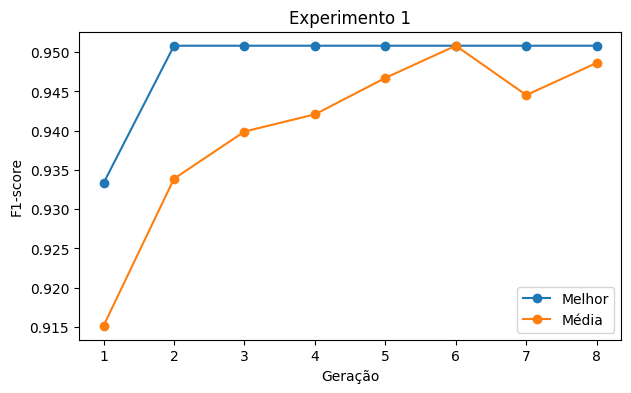

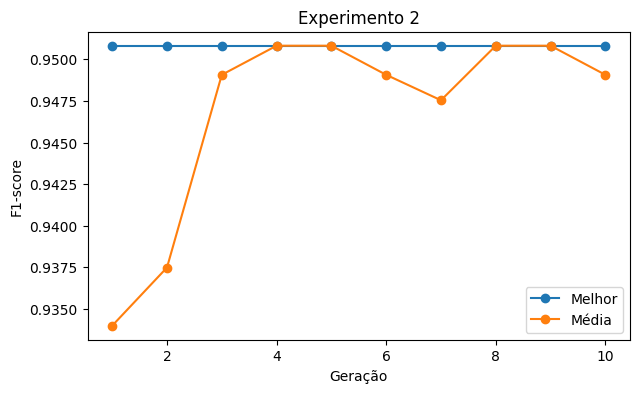

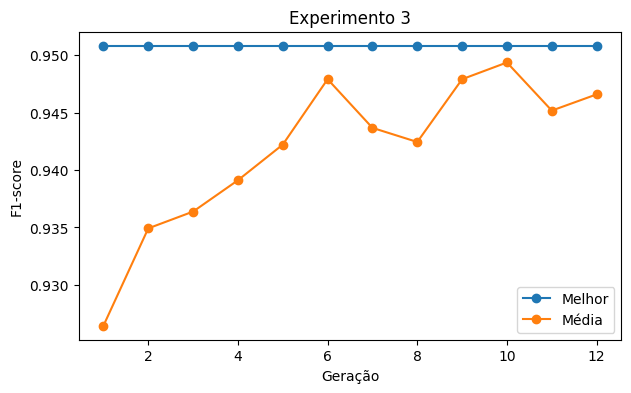

In [12]:
for i in range(3):

    melhor = resultados[i][2]
    media = resultados[i][3]

    plt.figure(figsize=(7, 4))

    plt.plot(range(1, len(melhor) + 1), melhor, marker="o", label="Melhor")
    plt.plot(range(1, len(media) + 1), media, marker="o", label="Média")

    plt.title("Experimento " + str(i + 1))
    plt.xlabel("Geração")
    plt.ylabel("F1-score")
    plt.legend()
    plt.show()

# 9. Melhor resultado dos experimentos

In [13]:
melhor_experimento = resultados[0]

for resultado in resultados:
    if resultado[1] > melhor_experimento[1]:
        melhor_experimento = resultado

melhores_parametros = melhor_experimento[0]

print("Melhor indivíduo encontrado:")
print(melhores_parametros)

print("F1 de validação:")
print(round(melhor_experimento[1], 4))

Melhor indivíduo encontrado:
[120, 10, 6, 'sqrt']
F1 de validação:
0.9508


# 10. Modelo otimizado

O melhor indivíduo será usado para criar o modelo final.

Os dados de treino e validação são unidos e o conjunto de teste continua separado para a avaliação final.

In [14]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

modelo_otimizado = RandomForestClassifier(
    n_estimators=melhores_parametros[0],
    max_depth=melhores_parametros[1],
    min_samples_split=melhores_parametros[2],
    max_features=melhores_parametros[3],
    random_state=42
)

modelo_otimizado.fit(X_train_final, y_train_final)

pred_otimizado = modelo_otimizado.predict(X_test)
proba_otimizado = modelo_otimizado.predict_proba(X_test)[:, 1]

accuracy_otimizado = accuracy_score(y_test, pred_otimizado)
recall_otimizado = recall_score(y_test, pred_otimizado)
f1_otimizado = f1_score(y_test, pred_otimizado)

print("Accuracy:", round(accuracy_otimizado, 4))
print("Recall:", round(recall_otimizado, 4))
print("F1-score:", round(f1_otimizado, 4))

Accuracy: 0.9884
Recall: 0.9688
F1-score: 0.9841


# 11. Comparação final

In [15]:
comparacao = pd.DataFrame({
    "Modelo": ["Original", "Otimizado"],
    "Accuracy": [accuracy_original, accuracy_otimizado],
    "Recall": [recall_original, recall_otimizado],
    "F1-score": [f1_original, f1_otimizado]
})

comparacao

,Modelo,Accuracy,Recall,F1-score
0,Original,0.976744,0.93750,0.967742
1,Otimizado,0.988372,0.96875,0.984127


# 12. Conclusão

Foram realizados três experimentos com diferentes tamanhos de população, quantidades de gerações e taxas de mutação.

O algoritmo genético utilizou quatro hiperparâmetros do Random Forest como genes. Durante as gerações, os indivíduos com melhor F1-score tiveram maior chance de gerar novos indivíduos por cruzamento e mutação.

Compare os valores da tabela final e descreva se o modelo otimizado apresentou melhora, manutenção ou redução em relação ao modelo original.

Também é possível analisar os gráficos para verificar se o fitness médio da população aumentou ao longo das gerações.

# Parte 2 — Observabilidade e Interpretação com LLM

As seções anteriores cobriram a busca de hiperparâmetros do Random Forest com Algoritmo Genético e a construção/avaliação do modelo final.

1. **Integração com uma LLM** (o **Claude**, da Anthropic) para transformar as saídas numéricas do Random Forest em explicações e insights acionáveis para médicos, com técnicas de **prompt engineering**;
2. Um **relatório executivo** consolidado gerado pela LLM;
3. **Avaliação da qualidade** das interpretações geradas pela LLM, combinando checagens heurísticas e LLM-as-judge.

O logging estruturado (decorator `monitor_call` usado nas chamadas ao Claude) é uma dependência direta das seções acima e também foi incorporado a este notebook.

In [16]:
# ============================================================
# 13. Logging estruturado e monitoramento
# ============================================================

from src.logging_utils import logger, monitor_call, performance_metrics

print("Logging estruturado configurado. Logs também salvos em 'pipeline_metrics.log'.")

Logging estruturado configurado. Logs também salvos em 'pipeline_metrics.log'.


## 14. Integração com Claude para interpretação dos resultados

Nesta seção, uma LLM pré-treinada — o **Claude** (Anthropic) — é integrada ao pipeline para:

- Transformar as saídas numéricas do Random Forest (probabilidade, acurácia, recall, F1-score) em **explicações em linguagem natural**;
- Gerar **insights acionáveis** para apoiar (nunca substituir) a decisão médica.

**Importante:** a LLM interpreta os *números já produzidos pelo Random Forest* — ela não realiza diagnóstico por conta própria, e o system prompt (Seção 15) deixa isso explícito, para reduzir o risco de alucinação ou de afirmações não respaldadas pelos dados.

In [17]:
# ============================================================
# 14. Setup do cliente Claude (Anthropic)
# ============================================================

!pip install -q anthropic

import anthropic
from src.llm import DEFAULT_MODEL

# Preferência: Colab Secrets (ícone de chave na barra lateral, nome ANTHROPIC_API_KEY).
# Isso evita expor a chave em texto plano na célula ou salvá-la no notebook.
ANTHROPIC_API_KEY = None

try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    ANTHROPIC_API_KEY = None

if not ANTHROPIC_API_KEY:
    import os
    ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY")

if not ANTHROPIC_API_KEY:
    from getpass import getpass
    ANTHROPIC_API_KEY = getpass(
        "Chave da API Anthropic não encontrada nos Secrets do Colab nem em variável de "
        "ambiente. Cole sua ANTHROPIC_API_KEY: "
    )

claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

# claude-haiku-4-5-20251001: menor custo/latência, útil sob alta demanda.
# claude-sonnet-5: equilíbrio custo/qualidade (padrão deste notebook).
# claude-opus-5: maior qualidade de raciocínio, custo mais alto.
CLAUDE_MODEL = DEFAULT_MODEL

print(f"Cliente Claude configurado. Modelo padrão: {CLAUDE_MODEL}")

You should consider upgrading via the '/Users/ph/playground/FIAP-TC-F02/.venv/bin/python3 -m pip install --upgrade pip' command.


Chave da API Anthropic não encontrada nos Secrets do Colab nem em variável de ambiente. Cole sua ANTHROPIC_API_KEY:  ········


Cliente Claude configurado. Modelo padrão: claude-sonnet-5


## 15. Estratégia de prompt engineering

Técnicas aplicadas nos prompts desta seção:

1. **System prompt com papel e restrições explícitas** — define o Claude como assistente de apoio à decisão clínica, nunca como fonte de diagnóstico definitivo, e limita as afirmações apenas aos dados fornecidos no prompt (reduz alucinação).
2. **Entrada estruturada em JSON** — em vez de texto livre, os dados do caso (probabilidade, métricas do modelo, hiperparâmetros escolhidos pelo AG) são serializados em JSON, o que reduz ambiguidade de interpretação pela LLM.
3. **Formato de saída fixado em seções** — o prompt exige que a resposta siga sempre: *Resumo*, *Interpretação dos números*, *Pontos de atenção*, *Sugestão de próximos passos*, *Limitações* — isso facilita tanto a leitura pelo médico quanto a avaliação automática de qualidade (Seção 19).
4. **Temperatura baixa (implícita no uso de valores determinísticos no prompt)** — prioriza consistência e aderência aos dados em vez de criatividade, adequado para contexto médico.
5. **Disclaimers obrigatórios** — o prompt exige que a resposta deixe explícito que se trata de apoio à decisão e que a palavra final é do profissional de saúde.

In [18]:
# ============================================================
# 15. System prompt e construção do payload do caso
# ============================================================

from src.llm import CLAUDE_SYSTEM_PROMPT, build_case_payload

# ============================================================
# 16. Chamada à LLM com retry e monitoramento
# ============================================================

from src.llm import explain_diagnosis_with_claude

## 17. Demonstração: explicações para casos reais do conjunto de teste

In [19]:
# ============================================================
# 17. Demonstração: explicações para casos reais do conjunto de teste
# ============================================================

# Seleciona 3 casos ilustrativos: um verdadeiro positivo, um falso negativo
# (o mais crítico clinicamente) e um verdadeiro negativo.
y_test_array = y_test.to_numpy()

demo_indices = {}

for i in range(len(y_test_array)):
    is_tp = y_test_array[i] == 1 and pred_otimizado[i] == 1
    is_fn = y_test_array[i] == 1 and pred_otimizado[i] == 0
    is_tn = y_test_array[i] == 0 and pred_otimizado[i] == 0

    if is_tp and "verdadeiro_positivo" not in demo_indices:
        demo_indices["verdadeiro_positivo"] = i
    elif is_fn and "falso_negativo" not in demo_indices:
        demo_indices["falso_negativo"] = i
    elif is_tn and "verdadeiro_negativo" not in demo_indices:
        demo_indices["verdadeiro_negativo"] = i

    if len(demo_indices) == 3:
        break

demo_explanations = {}

for label, idx in demo_indices.items():
    payload = build_case_payload(
        individuo=melhores_parametros,
        accuracy=accuracy_otimizado,
        recall=recall_otimizado,
        f1=f1_otimizado,
        prediction_probability=proba_otimizado[idx],
        predicted_class="Maligno" if pred_otimizado[idx] == 1 else "Benigno",
        true_class="Maligno" if y_test_array[idx] == 1 else "Benigno",
        clinical_notes=None,
    )

    explanation = explain_diagnosis_with_claude(claude_client, payload, model=CLAUDE_MODEL)
    demo_explanations[label] = {"payload": payload, "explanation": explanation}

    print("\n" + "=" * 80)
    print(f"CASO: {label} (índice {idx})")
    print("=" * 80)
    print(explanation)

{"timestamp": "2026-08-31T20:11:17", "level": "INFO", "message": "claude_explain_diagnosis finalizado em 8566.5ms (success)", "operation": "claude_explain_diagnosis", "duration_ms": 8566.45, "status": "success", "error": null}



CASO: verdadeiro_positivo (índice 0)
# Resumo

O modelo de Random Forest, com hiperparâmetros otimizados por algoritmo genético, classificou o caso analisado como **Maligno**, atribuindo uma probabilidade predita de **100% (1.0)** para essa classe. A classe real informada para validação retrospectiva também é "Maligno", indicando concordância entre a predição do modelo e o desfecho conhecido neste caso específico.

# Interpretação dos números

- **Probabilidade predita de malignidade: 1,0** — o modelo atribuiu confiança máxima à classificação maligna para as características tabulares deste exame, sem margem de incerteza indicada pela saída pontual.
- **Classe predita vs. classe real**: ambas coincidem ("Maligno"), o que sugere que, neste caso retrospectivo, o modelo teve acerto.
- **Métricas gerais do modelo** (não específicas deste caso, mas do desempenho no conjunto de teste):
  - Acurácia: 98,84% — alta taxa de acertos gerais.
  - Recall para a classe maligna: 96,88% — o modelo cap

{"timestamp": "2026-08-31T20:11:25", "level": "INFO", "message": "claude_explain_diagnosis finalizado em 7951.1ms (success)", "operation": "claude_explain_diagnosis", "duration_ms": 7951.05, "status": "success", "error": null}



CASO: verdadeiro_negativo (índice 1)
# Resumo

O modelo de Random Forest, otimizado por algoritmo genético, classificou o caso analisado como **Benigno**, com probabilidade estimada de malignidade de **2,2%**. A classificação predita coincide com a classe real informada para validação retrospectiva (Benigno). Não há notas clínicas adicionais associadas a este caso.

# Interpretação dos números

- **Probabilidade predita de malignidade (2,2%):** valor baixo, consistente com a classificação final atribuída pelo modelo ("Benigno"). Isso indica que, segundo os padrões numéricos aprendidos pelo modelo, as características do exame se assemelham predominantemente a casos historicamente benignos.
- **Métricas de desempenho do modelo no conjunto de teste:**
  - *Acurácia (98,84%)*: o modelo acerta a classificação na grande maioria dos casos do conjunto de teste utilizado em seu desenvolvimento.
  - *Recall para maligno (96,88%)*: em aproximadamente 97% dos casos malignos reais do conjunto de t

{"timestamp": "2026-08-31T20:11:33", "level": "INFO", "message": "claude_explain_diagnosis finalizado em 8606.6ms (success)", "operation": "claude_explain_diagnosis", "duration_ms": 8606.61, "status": "success", "error": null}



CASO: falso_negativo (índice 23)
# Resumo

O modelo de Random Forest, avaliado neste caso retrospectivo, classificou o exame como **"Benigno"**, com probabilidade predita de malignidade de **26,74%**. No entanto, a classe real informada para validação retrospectiva é **"Maligno"**, configurando um **falso negativo** — um dos cenários mais críticos em triagem oncológica, pois pode atrasar diagnóstico e tratamento.

# Interpretação dos números

- **Probabilidade predita de malignidade: 26,74%** — está abaixo do limiar de decisão padrão (tipicamente 50%), levando à classificação "Benigno". Contudo, esse valor não é desprezível e indica incerteza considerável do modelo, não uma confiança forte na benignidade.
- **Discrepância com a classe real**: o registro indica que o caso é, de fato, maligno. Isso caracteriza um **erro de tipo II (falso negativo)** — situação com maior risco clínico do que falsos positivos.
- **Métricas gerais do modelo**:
  - Acurácia geral: 98,84%
  - Recall para a c

## 18. Relatório executivo gerado pelo Claude

In [20]:
# ============================================================
# 18. Relatório executivo gerado pelo Claude
# ============================================================

from src.llm import generate_executive_summary_with_claude

pipeline_results = {
    "algoritmo_genetico": {
        "experimentos": [
            {
                "populacao": experimentos[i][0],
                "geracoes": experimentos[i][1],
                "taxa_mutacao": experimentos[i][2],
                "melhor_fitness_validacao": round(float(resultados[i][1]), 4),
            }
            for i in range(len(experimentos))
        ],
        "melhor_individuo": {
            "n_estimators": melhores_parametros[0],
            "max_depth": melhores_parametros[1],
            "min_samples_split": melhores_parametros[2],
            "max_features": melhores_parametros[3],
        },
        "melhor_fitness_validacao": round(float(melhor_experimento[1]), 4),
    },
    "random_forest_final_conjunto_teste": {
        "acuracia": round(float(accuracy_otimizado), 4),
        "recall_maligno": round(float(recall_otimizado), 4),
        "f1_score": round(float(f1_otimizado), 4),
    },
    "comparacao_com_baseline": {
        "acuracia_original": round(float(accuracy_original), 4),
        "recall_original": round(float(recall_original), 4),
        "f1_score_original": round(float(f1_original), 4),
        "delta_acuracia": round(float(accuracy_otimizado - accuracy_original), 4),
        "delta_recall": round(float(recall_otimizado - recall_original), 4),
        "delta_f1_score": round(float(f1_otimizado - f1_original), 4),
    },
}

executive_summary = generate_executive_summary_with_claude(claude_client, pipeline_results, model=CLAUDE_MODEL)

with open("relatorio_executivo_claude.md", "w", encoding="utf-8") as f:
    f.write(executive_summary)

print(executive_summary)
print("\nRelatório salvo em 'relatorio_executivo_claude.md'.")

{"timestamp": "2026-08-31T20:11:54", "level": "WARNING", "message": "Bloco de conteúdo inesperado recebido do Claude para resumo: ThinkingBlock", "unexpected_block_type": "ThinkingBlock", "block_content": "ThinkingBlock(signature='EssKCpABCBEYAipASxojxzlKzy1EEhXNNKZd6UbwV47aCwB8PQlNiW3SOq/VB9GOHHQiQmBvNwqvGNtrNpvSQKcELlajvrbihOg0BDIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiRkMWM5YTExMC0wNGJmLTQ1MWUtODQ0Ni0xYTYxYWYxYWNkNWWoAauU2NQGEgxAIBMUU1zMTDa/pKcaDGvtp6sUkbJxeiUJcyIw8uaofLepNGxSA/qIfW+0itYs7HotFqDGXIh1WMvFLXEBTL1ampEwjvZU/RAXm52sKucIQ6nxU2JQdmtbGjmsn7Di45iXsc6DOEWeaSGZi8aDxkLukJgWCyyIJJsY+iNajBfYmsEeKl6L6gX6+8JaSCMFfPJ7uw7gUQLxzAPcAog5qyhKRQAtakQOeZpiY6sJgVfbdvebVd8jxVC/fUQLcu59Y4ngZ7eafzru60ltUqv+wu56T8hPIXLoes+1fjRTh/sgC9qInG2hxpi5oRAamKtGteMoNY1tUp5qqJ5iUJoRCnXAf7DGXZBUSAA3AkIKZG7lbOb4sE3gnQqn5zW7XqeCCVz0N3g0VCMhlSTHjqDsk9RKPXG6iAOz1wx3HSqb2Zl0AxK5Y8caK3GslPlYFRQjpmchnrtS1coGZhp0OXXMXHvbGNDB8fsZNjBTlPIXX/7mEwFZQfqOhv+TFG3vyjJHT1TeZ5BiaHBbNwpGxWtQO6vrxcMw9F4SSwQhY3wMrZZELgPq8t5pzsT3T

# Relatório Executivo — Pipeline de Otimização e Classificação (Random Forest)

## Resumo

O pipeline avaliado utilizou um algoritmo genético para otimizar hiperparâmetros de um modelo Random Forest aplicado à classificação de exames de câncer de mama (benigno/maligno). Após três experimentos com diferentes configurações de população, gerações e taxa de mutação, o processo convergiu consistentemente para o mesmo valor de fitness de validação (0,9508), indicando estabilidade na busca. O modelo final, treinado com os hiperparâmetros otimizados, apresentou desempenho superior ao modelo baseline em todas as métricas avaliadas no conjunto de teste, com destaque para o ganho no recall da classe maligna.

## Interpretação dos números

O algoritmo genético testou três configurações (população 8/gerações 8, população 10/gerações 10 e população 12/gerações 12, com taxas de mutação de 0,1, 0,2 e 0,3, respectivamente). Todas convergiram para o mesmo melhor fitness de validação (0,9508), sugerindo 

## 19. Avaliação da qualidade das interpretações geradas

Duas camadas de avaliação são aplicadas às explicações geradas pelo Claude:

1. **Checagens heurísticas** — verificações determinísticas e baratas (não usam LLM): a explicação cita os números corretos do payload, segue o formato de seções exigido e evita linguagem de diagnóstico definitivo/absoluto.
2. **LLM-as-judge** — o próprio Claude é usado, em uma chamada independente, para pontuar cada explicação em uma rubrica de 1 a 5 em quatro critérios: clareza, fidelidade aos dados, utilidade clínica e segurança (ausência de afirmações não respaldadas).

Essa combinação é comum em pipelines de avaliação de LLM: heurísticas pegam falhas óbvias e baratas de checar; o LLM-as-judge cobre aspectos mais subjetivos (clareza, utilidade) que regras simples não capturam.

verdadeiro_positivo: {'cita_probabilidade_do_payload': True, 'sem_afirmacao_absoluta_proibida': True, 'todas_secoes_presentes': False, 'secoes_faltantes': ['Sugestão de próximos passos', 'Limitações'], 'tamanho_dentro_do_esperado': True}
verdadeiro_negativo: {'cita_probabilidade_do_payload': True, 'sem_afirmacao_absoluta_proibida': True, 'todas_secoes_presentes': False, 'secoes_faltantes': ['Sugestão de próximos passos', 'Limitações'], 'tamanho_dentro_do_esperado': True}
falso_negativo: {'cita_probabilidade_do_payload': False, 'sem_afirmacao_absoluta_proibida': True, 'todas_secoes_presentes': False, 'secoes_faltantes': ['Sugestão de próximos passos', 'Limitações'], 'tamanho_dentro_do_esperado': True}


{"timestamp": "2026-08-31T20:16:32", "level": "INFO", "message": "claude_judge_explanation finalizado em 10938.4ms (success)", "operation": "claude_judge_explanation", "duration_ms": 10938.43, "status": "success", "error": null}


verdadeiro_positivo: {'clareza': 5, 'fidelidade_aos_dados': 5, 'utilidade_clinica': 2, 'seguranca': 4, 'justificativa': 'Texto claro, bem estruturado e fiel aos dados fornecidos, sem invenção de achados. Menciona riscos de overconfidence e ausência de notas clínicas, reforçando cautela. Porém, a explicação está truncada antes de apresentar recomendações práticas (ex.: biópsia confirmatória, encaminhamento especializado), reduzindo sua utilidade clínica. A segurança é adequada, mas poderia ser mais explícita quanto à necessidade de confirmação diagnóstica humana.'}


{"timestamp": "2026-08-31T20:16:35", "level": "INFO", "message": "claude_judge_explanation finalizado em 3046.8ms (success)", "operation": "claude_judge_explanation", "duration_ms": 3046.76, "status": "success", "error": null}


verdadeiro_negativo: {'clareza': 5, 'fidelidade_aos_dados': 5, 'utilidade_clinica': 3, 'seguranca': 5, 'justificativa': 'Explicação clara, bem estruturada e fiel aos dados fornecidos, sem invenção de achados. Evita apresentar o resultado como diagnóstico definitivo, destacando incerteza e limitação das métricas. Porém, o texto está truncado ao final e não apresenta recomendações práticas explícitas (ex.: correlação clínica, exames complementares, acompanhamento), reduzindo a utilidade clínica.'}


{"timestamp": "2026-08-31T20:16:48", "level": "INFO", "message": "claude_judge_explanation finalizado em 12676.0ms (success)", "operation": "claude_judge_explanation", "duration_ms": 12675.95, "status": "success", "error": null}


falso_negativo: {'clareza': 4, 'fidelidade_aos_dados': 5, 'utilidade_clinica': 2, 'seguranca': 4, 'justificativa': 'A explicação é bem estruturada, usa linguagem acessível e interpreta corretamente os números fornecidos (probabilidade, recall, falso negativo) sem inventar dados. Mantém tom apropriadamente cauteloso, tratando o resultado como estimativa probabilística e não como diagnóstico definitivo. Contudo, o texto termina abruptamente sem apresentar recomendações concretas de conduta clínica (ex.: revisão manual, exames complementares, correlação clínica), reduzindo sua utilidade prática.'}


,caso,clareza,fidelidade_aos_dados,utilidade_clinica,seguranca,justificativa,heuristicas_ok
0,verdadeiro_positivo,5,5,2,4,"Texto claro, bem estruturado e fiel aos dados ...",3
1,verdadeiro_negativo,5,5,3,5,"Explicação clara, bem estruturada e fiel aos d...",3
2,falso_negativo,4,5,2,4,"A explicação é bem estruturada, usa linguagem ...",2


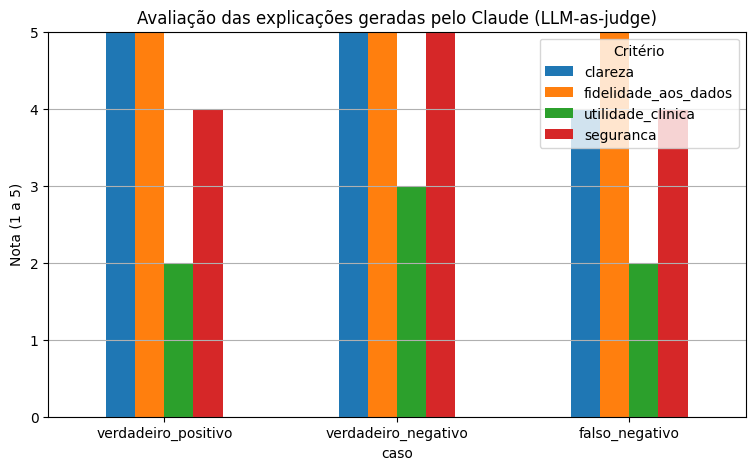

In [22]:
# ============================================================
# 19. Checagens heurísticas
# ============================================================

from src.quality import heuristic_quality_checks

for label, data in demo_explanations.items():
    checks = heuristic_quality_checks(data["explanation"], data["payload"])
    demo_explanations[label]["heuristic_checks"] = checks
    print(f"{label}: {checks}")

# ============================================================
# 20. Avaliação por LLM-as-judge
# ============================================================

from src.llm import judge_explanation_with_claude

for label, data in demo_explanations.items():
    scores = judge_explanation_with_claude(claude_client, data["payload"], data["explanation"], model=CLAUDE_MODEL)
    demo_explanations[label]["judge_scores"] = scores
    print(f"{label}: {scores}")

# ============================================================
# 21. Consolidação dos resultados de avaliação de qualidade
# ============================================================

quality_rows = []

for label, data in demo_explanations.items():
    row = {"caso": label}
    row.update(data.get("judge_scores", {}))
    row["heuristicas_ok"] = sum(
        1 for k, v in data.get("heuristic_checks", {}).items()
        if isinstance(v, bool) and v
    )
    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

criteria = ["clareza", "fidelidade_aos_dados", "utilidade_clinica", "seguranca"]
available_criteria = [c for c in criteria if c in quality_df.columns]

if available_criteria:
    quality_df.set_index("caso")[available_criteria].plot(
        kind="bar", figsize=(9, 5)
    )
    plt.title("Avaliação das explicações geradas pelo Claude (LLM-as-judge)")
    plt.ylabel("Nota (1 a 5)")
    plt.ylim(0, 5)
    plt.xticks(rotation=0)
    plt.legend(title="Critério")
    plt.grid(axis="y")
    plt.show()

**Limitações da avaliação de qualidade:**

- A amostra de demonstração é pequena (3 casos); em um cenário de produção, essa avaliação deveria rodar sobre um conjunto muito maior e de forma contínua (amostragem dos casos reais processados).
- **LLM-as-judge tem viés conhecido**: um modelo pode favorecer respostas geradas por modelos da mesma família. O ideal em produção é complementar com revisão humana periódica (amostragem por um profissional de saúde), especialmente antes de qualquer uso clínico real.
- As checagens heurísticas são propositalmente simples (regras de string) — pegam falhas grosseiras, mas não substituem uma auditoria de conteúdo clínico.
- Este pipeline é um **protótipo educacional**: nenhuma saída deste notebook deve ser usada para decisão clínica real sem validação regulatória e clínica apropriada.

## 22. Conclusão geral

O Random Forest otimizado por Algoritmo Genético (Seções 1–12) foi combinado com uma camada de interpretação por LLM (Seções 14–18) e com uma avaliação automática de qualidade das explicações geradas (Seções 19–21).

**Fluxo final deste arquivo:**

```
Wisconsin Breast Cancer Dataset (Kaggle)
   │
   ▼
Preparação dos dados (treino/validação/teste)
   │
   ▼
Random Forest original (baseline)
   │
   ▼
Algoritmo Genético (busca de hiperparâmetros do Random Forest, usa treino/validação)
   │
   ▼
Random Forest final treinado com o melhor indivíduo
   │
   ├──▶ Avaliação no conjunto de teste (acurácia, recall, F1-score)
   │
   ▼
Camada de interpretação com Claude (Seções 14–18)
   │  - explicações em linguagem natural por caso
   │  - relatório executivo agregado
   │
   ▼
Avaliação de qualidade das explicações (Seções 19–21)
   │  - checagens heurísticas
   │  - LLM-as-judge
```